# Warmest welcome!So glad that you are here! 
 

# An UPVOTE would be awesome if you liked the kernel.


# Problem statement

The first thing we have to do is getting a crystal clear idea about what exactly we are trying to find out. In this particular case, the problem statement
is actually super straight-forward. We have to build a model that takes years of experience as input and predict the salary based on that.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Importing the dataset

In [2]:
df = pd.read_csv("/kaggle/input/salary-data-simple-linear-regression/Salary_Data.csv")

In [3]:
'''We just imported our dataset. Now we want to view the first 5 rows of the data, for which we will use
pandas head() method'''


df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


# Let's understand the dataset! 😃

YearsExperience - It shows number of years of experience an employee has.

Salary - It shows corresponding salaries (in thousand) based on years of experience.

In [4]:
print(f'The shape of the dataset is {df.shape}')




The shape of the dataset is (30, 2)


In [5]:
'''Information about every column of this dataset'''

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 608.0 bytes


In [6]:
'''Checking if there is any null values in data'''

df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

<AxesSubplot:>

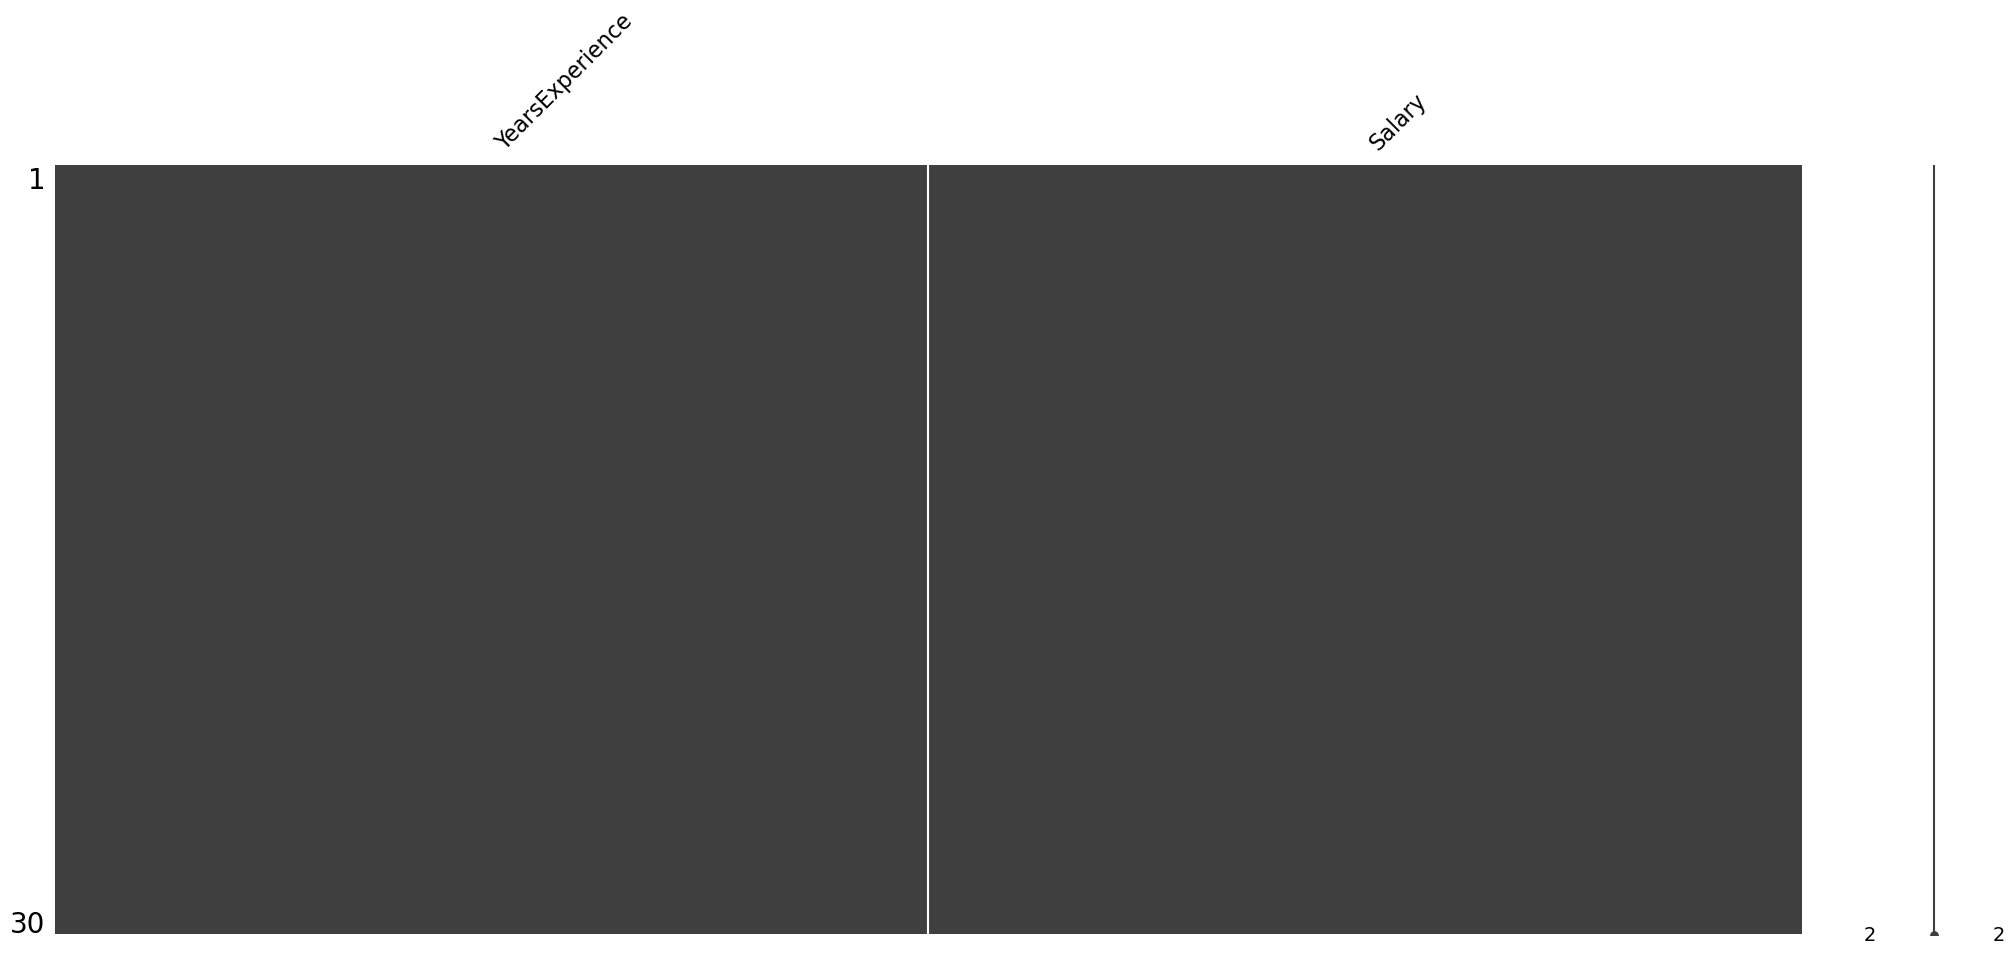

In [7]:
'''We can also visually represent that there is no missing data in the dataset'''


import missingno as msn
msn.matrix(df)

In [8]:
'''Statistical summary of the dataframe'''

df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


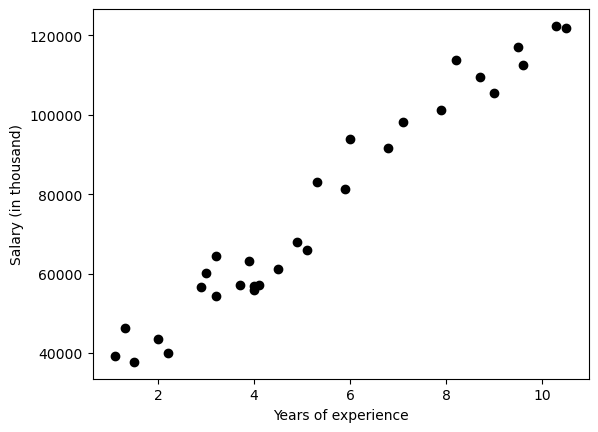

In [9]:
plt.scatter(df['YearsExperience'],df['Salary'],c='black')
plt.xlabel("Years of experience")
plt.ylabel("Salary (in thousand)")
plt.show()

# Split the dataset

Now we have to split the dataset into two parts, independent variable(Predictor) and 
dependent variable(target). We know, how much salary you will get is (usually) dependent of how many 
experience do you have in that respective field. So in our case the dependent variable is Salary and 
the independent variable is YearsExperience. Let's split the data into X (predictor) and Y (target)!

In [10]:
X = df[['YearsExperience']]

In [11]:
Y = df.iloc[:,-1]

# Train Test Split

In [12]:
from sklearn.model_selection import train_test_split


- The training data is the data set used to train the machine learning model.


- The testing data is used to evaluate the performance of the trained model.It is used to estimate how well the model will perform on new, unseen data.








**Simple Explanation by an example**
____________

**Suppose, I have 10 data that I can feed the ml model but I will not feed all 10 data, instead I will feed 8 data to the model
and keep rest 2 data to myself. After feeding the 8 data I will ask the model to predict that 2 data which is though new
for the ml model but I already know the answer as I have that 2 data. After getting the result from the model I will cross 
check if the answer is valid or not so that I can measure how much my model has actually learnt. 
Here that 8 data are train data and 2 data are test data.**



In [13]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=1)

• We will use Linear Regression model here. A question may arise why Linear regression as there are so many other algorithms available in ml?


Ans : The main purpose of using linear regression in machine learning is to predict a continuous(numerical) output variable based on one or more input variables. As the output variable(Salary) is continuous so we will use Linear regression model here
Also  Linear regression is a simple and straightforward model to implement and interpret, making it a good choice for beginners in machine learning. The coefficients of the model provide insight into how each input variable affects the output variable, making it easy to understand and explain the results.
.

In [14]:
from sklearn.linear_model import LinearRegression

In [15]:
# Initialize a linear regression model object

lin_reg = LinearRegression()

In [16]:
lin_reg.fit(X_train,Y_train)

LinearRegression()

In [17]:
Y_pred = lin_reg.predict(X_train)

In [18]:
Y_valtest_pred = lin_reg.predict(X_test)

**Let's see regression line of our model.**

Text(0, 0.5, 'Salary (in thousand)')

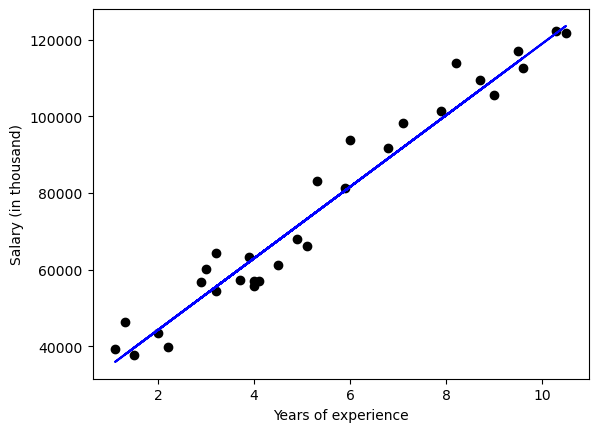

In [19]:
plt.scatter(X,Y,color='black')
plt.plot(X_train,Y_pred,color='blue')
plt.xlabel('Years of experience')
plt.ylabel('Salary (in thousand)')

# **Model Evaluation**

Now we will check the accuracy/efficiency of our model that how well did our model perform. Actually there are several method for doing that. As a beginner, it's better fro you to try some of them and then choose which method you will use. Some of the popular technique for model evaluation are:
 - Mean Absolute Error (MAE)
 - Mean Squared Error (MSE)
 - Root Mean Squared Error (RMSE)
 - R_2 score
 
Let's try each of them one by one!


N:B: Salary is given in thousand in this dataset

In [20]:
from sklearn.metrics import mean_absolute_error
print(f'The value of MAE is {mean_absolute_error(Y_test,Y_valtest_pred)}')

The value of MAE is 6185.994575326634


In [21]:
from sklearn.metrics import mean_squared_error
print(f'The value of MSE is {mean_squared_error(Y_test,Y_valtest_pred)}')

The value of MSE is 51338023.49224842


There is no direct way to find RMSE. As RMSE is nothing but the square root of MSE
so what we can do is we will just square root the value of MSE by using 
numpy's square root function

In [22]:
print('The value of RMSE is ',np.sqrt(mean_squared_error(Y_test,Y_valtest_pred)))

The value of RMSE is  7165.055721503387


In [23]:
from sklearn.metrics import r2_score
print(f"R_2 score is {r2_score(Y_test,Y_valtest_pred)}")

R_2 score is 0.7616681465472094


# Estimating the equation of Regression line

The equation of a regression line is a mathematical formula that represents the relationship between the 
independent variable (x) and the dependent variable (y) in a linear regression model.
In its simplest form, the equation of a regression line can be represented as:

# y = β1x + β0

where:

y is the predicted value of the dependent variable

x is the value of the independent variable

β1 s the slope of the regression line, which represents the change in y for a unit change in x

β0 s the y-intercept of the regression line, which represents the value of y when x is equal to 0.

In [24]:
'''Finding the value of slope (β1) '''

β1 = lin_reg.coef_
print(f'The value of slope is {β1}')

The value of slope is [9332.94473799]


In [25]:
'''Finding the value of intercept (β0)'''

β0 = lin_reg.intercept_
print(f'The value of intercept is {β0}')

The value of intercept is 25609.89799835482


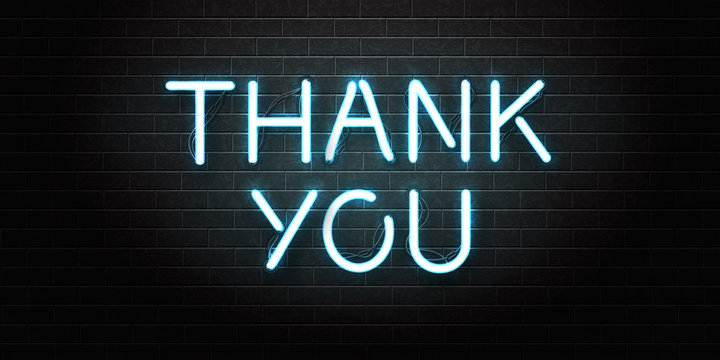